In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
from pathlib import Path
from lmfit.models import VoigtModel, LinearModel
import dataclasses

In [137]:
@dataclasses.dataclass
class peaksetup:
    center: float
    weight: float
    min: float | None
    max: float | None
    label: str

In [138]:
def fit_flexible_pl(x, y, peaks_setup: list[peaksetup], x_range=(1.5, 1.8)):
    # 1. 解析範囲のクリッピング
    mask = (x >= x_range[0]) & (x <= x_range[1])
    x_fit, y_fit = x[mask], y[mask]

    # 2. 背景モデルの初期化
    model = LinearModel(prefix='bkg_')
    params = model.make_params(slope=0, intercept=np.min(y_fit))

    # 3. 引数で指定されたピークを動的に追加
    for i, p_config in enumerate(peaks_setup):
        prefix = f'p{i}_'
        p_model = VoigtModel(prefix=prefix)
        model += p_model
        
        params.update(p_model.make_params())
        params[f'{prefix}center'].set(
            value=p_config.center,
            min=p_config.min if p_config.min is not None else p_config.center - 0.05,
            max=p_config.max if p_config.max is not None else p_config.center + 0.05
        )
        params[f'{prefix}amplitude'].set(value=np.max(y_fit) * p_config.weight, min=0)
        params[f'{prefix}sigma'].set(value=0.01, min=0.001)

    # 4. フィッティング実行
    result = model.fit(y_fit, params, x=x_fit)
    return result

In [139]:
def load_horizontal_pl(file_path) -> tuple:
    df = pd.read_csv(file_path, sep='\t', header=None)
    energy = df.iloc[:, 0].values
    intensity = df.iloc[:, 1].values
    return energy, intensity

In [140]:
def load_horizontal_pl_map(file_path) -> tuple:
    df = pd.read_csv(file_path, sep='\t', header=None)

    # 1. エネルギー軸（1行目の3列目以降）
    energy = df.iloc[0, 2:].astype(float).values

    # 2. 座標データ（2行目以降の1〜2列目）
    x_coords = df.iloc[1:, 0].astype(float).values
    y_coords = df.iloc[1:, 1].astype(float).values

    # 3. 強度マトリックス（2行目以降の3列目以降）
    # 行が各測定点、列が各エネルギー点に対応する
    intensities = df.iloc[1:, 2:].astype(float).values

    print(f"エネルギー点数: {len(energy)}")
    print(f"測定点数: {len(x_coords)}")
    print(f"強度データの形状: {intensities.shape}")
    
    return x_coords, y_coords, energy, intensities

エネルギー点数: 1024
測定点数: 220
強度データの形状: (220, 1024)
座標: (-4.84, -1.83)


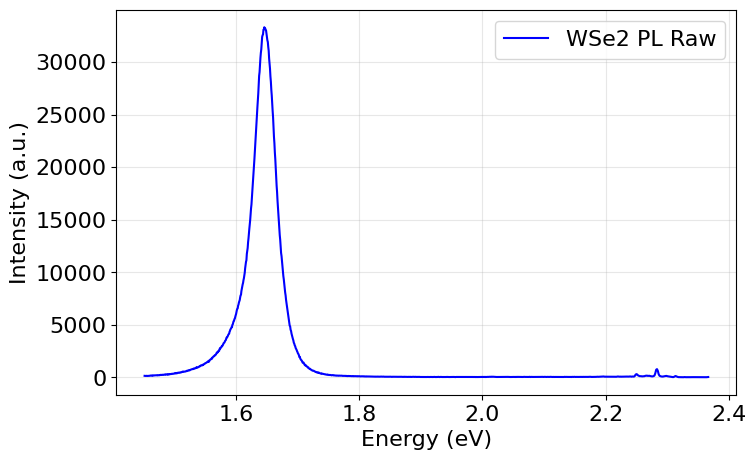

In [166]:
file_path = Path("data/pl/WSe2_PL_D1_1s_1accumulation_50X.txt")
x, y, energy, intensities = load_horizontal_pl_map(file_path)
target_index = 169
print(f"座標: ({x[target_index]:.2f}, {y[target_index]:.2f})")


# プロット
plt.figure(figsize=(8, 5))
plt.plot(energy, intensities[target_index, :], color='b', label=f"WSe2 PL Raw")
plt.xlabel("Energy (eV)", fontsize=16)
plt.ylabel("Intensity (a.u.)", fontsize=16)
plt.tick_params(axis='both', labelsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=16)
plt.savefig(f"output/pl/wse2_pl_spectrum_{target_index}.png", dpi=300)

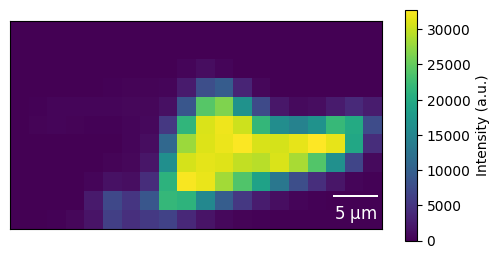

In [142]:
def save_mapping(x, y, energy, intensities, target_peak=1.65, save_dir=Path("output/pl")):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    target_idx = np.argmin(np.abs(energy - target_peak))
    mapped_intensities = intensities[:, target_idx]
    
    df_map = pd.DataFrame({'X': y, 'Y': x, 'Intensity': mapped_intensities})
    pivot_table = df_map.pivot(index='Y', columns='X', values='Intensity')
    
    # グラフ描画用のX, Yグリッドと強度データ(C)を取得
    x_unique = pivot_table.columns.values
    y_unique = pivot_table.index.values
    C = pivot_table.values
    
    # マッピング結果を図示 
    fig, ax = plt.subplots(figsize=(6, 5))
    sc = ax.pcolormesh(x_unique, y_unique, C, shading="auto", cmap='viridis')
    
    scalebar = ScaleBar(1, "um", length_fraction=0.2, location="lower right", 
                        box_alpha=0, color="white", font_properties={'size': 12})
    ax.add_artist(scalebar)
    plt.colorbar(sc, label=f'Intensity (a.u.)', shrink=0.6, aspect=20, pad=0.05)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)
    plt.savefig(save_dir / f"wse2_pl_mapping_{target_peak:.2f}eV.png", dpi=300, bbox_inches='tight')
    plt.show()

save_mapping(x, y, energy, intensities, target_peak=1.65)

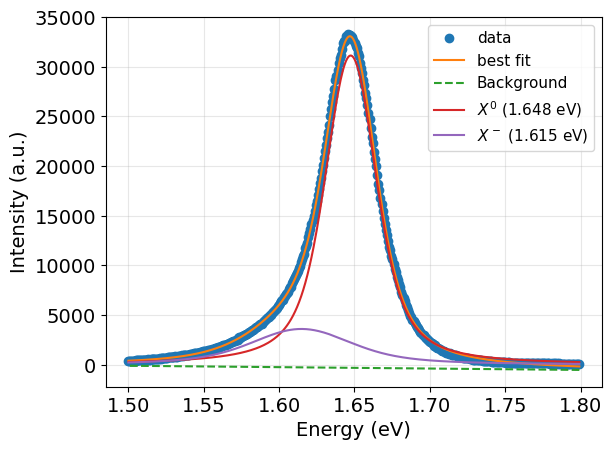

In [155]:
try:
    peaksetups = [
        peaksetup(center=1.65, weight=0.5, min=None, max=None, label="$X^0$"),
        peaksetup(center=1.62, weight=0.5, min=None, max=None, label="$X^-$"),
    ]
    res = fit_flexible_pl(energy, intensities[target_index, :], peaks_setup=peaksetups, x_range=(1.5, 1.8))
    if not res.success:
        print("Fit did not converge:", res.message)
        raise ValueError("Fit failed")
    res.plot_fit(numpoints=1000)
    ax = plt.gca()
    
    assert res.userkws is not None
    x_fit = res.userkws['x']
    comps = res.eval_components(x=x_fit)
    
    ax.plot(x_fit, comps['bkg_'], '--', label='Background')
    for i, peak in enumerate(peaksetups):
        prefix = f'p{i}_'
        if prefix in comps:
            fitted_center = res.params[f'{prefix}center'].value
            ax.plot(x_fit, comps[prefix], '-', label=f'{peak.label} ({fitted_center:.3f} eV)')
    
    best_fit_y = res.best_fit
    max_idx = np.argmax(best_fit_y)
    best_fit_peak = x_fit[max_idx]
    ax.set_title("")
    ax.set_xlabel("Energy (eV)", fontsize=14)
    ax.set_ylabel("Intensity (a.u.)", fontsize=14)
    ax.tick_params(axis='both', labelsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)
    plt.show()
    plt.show()

except Exception as e:
    print(f"Error: {e}")